<a href="https://colab.research.google.com/github/GourieG/GenAI-Internship/blob/main/Day5/NLP_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

df=pd.read_csv("/content/jobs.csv")
print(df)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                            job_title  \
0                                    Python Developer   
1                                    Python Developer   
2                             Junior Python Developer   
3                                    Python Developer   
4                                    PYTHON DEVELOPER   
5                          Software Engineer (Junior)   
6                          Python Developer , Officer   
7                        Python API Engineer Contract   
8                        Python API Engineer Contract   
9                                    Python Developer   
10                                   Python Developer   
11                       Senior Staff Python Engineer   
12                                   Python Developer   
13                         Python Developer (GC--USC)   
14                             Python Developer (AWS)   
15                                   Python Developer   
16                            S

In [2]:
df['job_title_lower'] = df['job_title'].str.lower()
display(pd.concat([df['job_title'], df['job_title_lower']], axis=1).head())

,job_title,job_title_lower
0,Python Developer,python developer
1,Python Developer,python developer
2,Junior Python Developer,junior python developer
3,Python Developer,python developer
4,PYTHON DEVELOPER,python developer


In [3]:
df['tokens'] = df['job_title_lower'].apply(word_tokenize)
display(df[['job_title_lower', 'tokens']].head())

,job_title_lower,tokens
0,python developer,"[python, developer]"
1,python developer,"[python, developer]"
2,junior python developer,"[junior, python, developer]"
3,python developer,"[python, developer]"
4,python developer,"[python, developer]"


In [4]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)
display(pd.concat([df['tokens'], df['tokens_no_stopwords']], axis=1).head())

,tokens,tokens_no_stopwords
0,"[python, developer]","[python, developer]"
1,"[python, developer]","[python, developer]"
2,"[junior, python, developer]","[junior, python, developer]"
3,"[python, developer]","[python, developer]"
4,"[python, developer]","[python, developer]"


In [5]:
stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemmed_tokens'] = df['tokens_no_stopwords'].apply(apply_stemming)
display(pd.concat([df['tokens_no_stopwords'], df['stemmed_tokens']], axis=1).head(10))

,tokens_no_stopwords,stemmed_tokens
0,"[python, developer]","[python, develop]"
1,"[python, developer]","[python, develop]"
2,"[junior, python, developer]","[junior, python, develop]"
3,"[python, developer]","[python, develop]"
4,"[python, developer]","[python, develop]"
5,"[software, engineer, (, junior, )]","[softwar, engin, (, junior, )]"
6,"[python, developer, ,, officer]","[python, develop, ,, offic]"
7,"[python, api, engineer, contract]","[python, api, engin, contract]"
8,"[python, api, engineer, contract]","[python, api, engin, contract]"
9,"[python, developer]","[python, develop]"


In [6]:
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_tokens'] = df['tokens_no_stopwords'].apply(apply_lemmatization)
display(pd.concat([df['stemmed_tokens'], df['lemmatized_tokens']], axis=1).head(10))

,stemmed_tokens,lemmatized_tokens
0,"[python, develop]","[python, developer]"
1,"[python, develop]","[python, developer]"
2,"[junior, python, develop]","[junior, python, developer]"
3,"[python, develop]","[python, developer]"
4,"[python, develop]","[python, developer]"
5,"[softwar, engin, (, junior, )]","[software, engineer, (, junior, )]"
6,"[python, develop, ,, offic]","[python, developer, ,, officer]"
7,"[python, api, engin, contract]","[python, api, engineer, contract]"
8,"[python, api, engin, contract]","[python, api, engineer, contract]"
9,"[python, develop]","[python, developer]"


In [7]:
from sklearn.feature_extraction.text import CountVectorizer

First, we need to join the lemmatized tokens back into strings, as `CountVectorizer` expects text input rather than lists of tokens.

In [8]:
df['lemmatized_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))
display(df[['lemmatized_tokens', 'lemmatized_text']].head())

,lemmatized_tokens,lemmatized_text
0,"[python, developer]",python developer
1,"[python, developer]",python developer
2,"[junior, python, developer]",junior python developer
3,"[python, developer]",python developer
4,"[python, developer]",python developer


Now, let's initialize `CountVectorizer` and fit it to our lemmatized text. We'll then transform the text into a document-term matrix.

In [9]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['lemmatized_text'])

Let's inspect the vocabulary learned by the `CountVectorizer`.

In [10]:
print("Vocabulary:", vectorizer.vocabulary_)

Vocabulary: {'python': 19, 'developer': 7, 'junior': 14, 'software': 24, 'engineer': 8, 'officer': 17, 'api': 2, 'contract': 5, 'senior': 23, 'staff': 26, 'gc': 10, 'usc': 27, 'aws': 3, 'ai': 1, 'data': 6, 'scientist': 21, 'founding': 9, 'quant': 20, 'backend': 4, 'sdk': 22, 'growth': 11, 'infrastructure': 12, 'agent': 0, 'intermediate': 13, 'product': 18, 'solution': 25, 'machine': 16, 'learning': 15}


Here are the feature names (tokens) generated by the `CountVectorizer`.

In [11]:
feature_names = vectorizer.get_feature_names_out()
print("Feature Names:", feature_names)

Feature Names: ['agent' 'ai' 'api' 'aws' 'backend' 'contract' 'data' 'developer'
 'engineer' 'founding' 'gc' 'growth' 'infrastructure' 'intermediate'
 'junior' 'learning' 'machine' 'officer' 'product' 'python' 'quant'
 'scientist' 'sdk' 'senior' 'software' 'solution' 'staff' 'usc']


Finally, let's look at the shape of the resulting document-term matrix and a small portion of it to see the counts.

In [12]:
print("Shape of the CountVectorizer matrix:", X.shape)
# Display a part of the matrix (e.g., first 5 rows and corresponding feature names)
print("First 5 rows of the CountVectorizer matrix (sparse format):\n", X[:5])

# To see it in a more readable dense format (caution for large datasets)
df_count_vectorizer = pd.DataFrame(X.toarray(), columns=feature_names)
display(df_count_vectorizer.head())

Shape of the CountVectorizer matrix: (32, 28)
First 5 rows of the CountVectorizer matrix (sparse format):
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11 stored elements and shape (5, 28)>
  Coords	Values
  (0, 19)	1
  (0, 7)	1
  (1, 19)	1
  (1, 7)	1
  (2, 19)	1
  (2, 7)	1
  (2, 14)	1
  (3, 19)	1
  (3, 7)	1
  (4, 19)	1
  (4, 7)	1


,agent,ai,api,aws,backend,contract,data,developer,engineer,founding,...,product,python,quant,scientist,sdk,senior,software,solution,staff,usc
0,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

Now, let's initialize `TfidfVectorizer` and fit it to our lemmatized text. This will convert the text data into TF-IDF (Term Frequency-Inverse Document Frequency) features.

In [14]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['lemmatized_text'])

Let's inspect the vocabulary learned by the `TfidfVectorizer`.

In [15]:
print("TF-IDF Vocabulary:", tfidf_vectorizer.vocabulary_)

TF-IDF Vocabulary: {'python': 19, 'developer': 7, 'junior': 14, 'software': 24, 'engineer': 8, 'officer': 17, 'api': 2, 'contract': 5, 'senior': 23, 'staff': 26, 'gc': 10, 'usc': 27, 'aws': 3, 'ai': 1, 'data': 6, 'scientist': 21, 'founding': 9, 'quant': 20, 'backend': 4, 'sdk': 22, 'growth': 11, 'infrastructure': 12, 'agent': 0, 'intermediate': 13, 'product': 18, 'solution': 25, 'machine': 16, 'learning': 15}


Here are the feature names (tokens) generated by the `TfidfVectorizer`.

In [16]:
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
print("TF-IDF Feature Names:", tfidf_feature_names)

TF-IDF Feature Names: ['agent' 'ai' 'api' 'aws' 'backend' 'contract' 'data' 'developer'
 'engineer' 'founding' 'gc' 'growth' 'infrastructure' 'intermediate'
 'junior' 'learning' 'machine' 'officer' 'product' 'python' 'quant'
 'scientist' 'sdk' 'senior' 'software' 'solution' 'staff' 'usc']


Finally, let's look at the shape of the resulting TF-IDF matrix and a small portion of it to see the TF-IDF scores.

In [17]:
print("Shape of the TfidfVectorizer matrix:", X_tfidf.shape)
# Display a part of the matrix (e.g., first 5 rows and corresponding feature names)
print("First 5 rows of the TfidfVectorizer matrix (sparse format):\n", X_tfidf[:5])

# To see it in a more readable dense format (caution for large datasets)
df_tfidf_vectorizer = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_feature_names)
display(df_tfidf_vectorizer.head())

Shape of the TfidfVectorizer matrix: (32, 28)
First 5 rows of the TfidfVectorizer matrix (sparse format):
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11 stored elements and shape (5, 28)>
  Coords	Values
  (0, 19)	0.7182475933670411
  (0, 7)	0.6957876074079313
  (1, 19)	0.7182475933670411
  (1, 7)	0.6957876074079313
  (2, 19)	0.34982554404475474
  (2, 7)	0.33888631239268574
  (2, 14)	0.8733717169720339
  (3, 19)	0.7182475933670411
  (3, 7)	0.6957876074079313
  (4, 19)	0.7182475933670411
  (4, 7)	0.6957876074079313


,agent,ai,api,aws,backend,contract,data,developer,engineer,founding,...,product,python,quant,scientist,sdk,senior,software,solution,staff,usc
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.695788,0.0,0.0,...,0.0,0.718248,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.695788,0.0,0.0,...,0.0,0.718248,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.338886,0.0,0.0,...,0.0,0.349826,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.695788,0.0,0.0,...,0.0,0.718248,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.695788,0.0,0.0,...,0.0,0.718248,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

To create a Word Cloud, we first need to concatenate all the lemmatized job titles into a single string.

In [19]:
all_lemmatized_text = ' '.join(df['lemmatized_text'])
print(f"Length of combined text: {len(all_lemmatized_text)} characters")

Length of combined text: 772 characters


Now, let's generate and display the Word Cloud. This visualization will highlight the most prominent words in your `job_title` data.

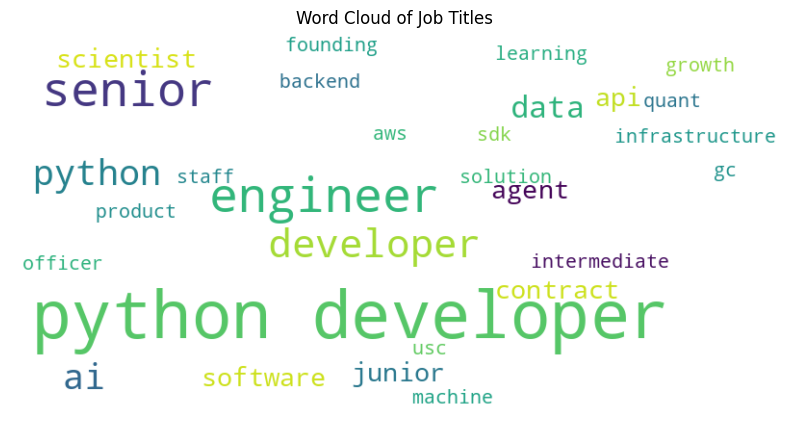

In [20]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_lemmatized_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Job Titles')
plt.show()